# How Close Can I Get to Vegas Lines with Free Data?

**Notebook Overview**  

 In this notebook, we:
 1. Fetch and prepare Ja Morant's performance logs from the NBA API.
 2. Merge with betting data (spreads) from a Kaggle dataset.
 3. Engineer features (e.g., rest days, rolling averages).
 4. Train and compare multiple models (Linear, Ridge, Lasso, RF, XGBoost, LightGBM).
 5. Perform hyperparameter tuning (Ridge, RF) to improve predictions.
 6. Evaluate results and plot outcomes.

## 1. Imports and Setup
 Import libraries for data retrieval, manipulation, visualization, and model training/evaluation.


In [3]:
import pandas as pd
from itables import show
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.library.parameters import SeasonAll
from nba_api.stats.static import players, teams
import json
import requests
import matplotlib.pyplot as plt
import string
import time
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import pandas as pd
from summarytools import dfSummary
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

## 2. Fetch Ja Morant Game Logs
Retrieve all available game logs for Kevin Durant.

In [4]:
ja_morant_stats = playergamelog.PlayerGameLog(player_id='201942', season=SeasonAll.all)
player_stats = ja_morant_stats.get_data_frames()[0]

## 3. Feature Engineering
 Create new features such as intradivisional games, rest categories, and rolling averages.

In [5]:
nba_divisions = {
    "Eastern Conference": {
        "ATLANTIC": ["BOS", "BKN", "NYK", "PHI", "TOR"],
        "CENTRAL": ["CHI", "CLE", "DET", "IND", "MIL"],
        "SOUTHEAST": ["ATL", "CHA", "MIA", "ORL", "WAS"]
    },
    "Western Conference": {
        "NORTHWEST": ["DEN", "MIN", "OKC", "POR", "UTA"],
        "PACIFIC": ["GSW", "LAC", "LAL", "PHX", "SAC"],
        "SOUTHWEST": ["DAL", "HOU", "MEM", "NOP", "SAS"]
    }
}

def extract_teams(matchup):
    if " @ " in matchup:
        return matchup.split(" @ ")
    elif " vs. " in matchup:
        return matchup.split(" vs. ")
    return None, None

def find_division(team_name):
    for conference, divisions in nba_divisions.items():
        for division, teams in divisions.items():
            if team_name in teams:
                return division
    return None

def is_interdivisional(player_team, opponent):
    player_division = find_division(player_team)
    opponent_division = find_division(opponent)
    if player_division and opponent_division and player_division != opponent_division:
        for conference, divisions in nba_divisions.items():
            if player_team in sum(divisions.values(), []) and opponent in sum(divisions.values(), []):
                return 1
    return 0

def classify_rest_days(days):
    if days < 2:
        return 'Less than 2 days'
    elif 2 <= days <= 3:
        return '2-3 days'
    else:
        return 'More than 3 days'

def add_home_away_teams(dataframe):
    def split_matchup(row):
        if "vs." in row['MATCHUP']:
            return pd.Series([row['Player_Team'], row['Opponent']], index=['Home_Team', 'Away_Team'])
        elif "@" in row['MATCHUP']:
            return pd.Series([row['Opponent'], row['Player_Team']], index=['Home_Team', 'Away_Team'])
        return pd.Series([None, None], index=['Home_Team', 'Away_Team'])
    dataframe[['Home_Team', 'Away_Team']] = dataframe.apply(split_matchup, axis=1)
    return dataframe
stats_columns = [
    'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 
    'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 
    'PTS', 'PLUS_MINUS'
]
columns_to_modify = [
    'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 
    'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 
    'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS'
]

In [6]:
player_stats['GAME_DATE'] = pd.to_datetime(player_stats['GAME_DATE'])
player_stats['Player_Team'], player_stats['Opponent'] = zip(*player_stats['MATCHUP'].apply(extract_teams))
player_stats['Home_Court_Advantage'] = player_stats['MATCHUP'].apply(lambda x: 1 if 'vs.' in x else 0)
player_stats['Interdivisional_Game'] = player_stats.apply(lambda x: is_interdivisional(x['Player_Team'], x['Opponent']), axis=1)
player_stats = player_stats.sort_values(by=['SEASON_ID', 'Player_ID', 'GAME_DATE']).reset_index(drop=True)
player_stats['Rest_Days'] = player_stats.groupby(['SEASON_ID', 'Player_ID'])['GAME_DATE'].diff().dt.days
player_stats['Rest_Days'] = player_stats['Rest_Days'].fillna(0).astype(int)
player_stats['Rest_Category'] = player_stats['Rest_Days'].apply(classify_rest_days)
rest_category_dummies = pd.get_dummies(player_stats['Rest_Category'])
rest_category_dummies.columns = ['Rest_Category_' + str(col) for col in rest_category_dummies.columns]
player_stats = pd.concat([player_stats, rest_category_dummies], axis=1)
player_stats = add_home_away_teams(player_stats)
rest_category_dummies = pd.get_dummies(player_stats['Rest_Category'])
rest_category_dummies.columns = ['Rest_Category_' + str(col) for col in rest_category_dummies.columns]
player_stats = pd.concat([player_stats, rest_category_dummies], axis=1)
player_stats["Target"] = player_stats['PTS']
player_stats = player_stats.loc[player_stats["Target"] != 0].dropna(subset=["Target"])
for col in columns_to_modify:
    per_min_col_name = f"{col}_per_min"
    player_stats[per_min_col_name] = player_stats[col] / player_stats['MIN']

# Compute rolling averages for per-minute metrics
rolling_windows = [3, 7, 15]
for col in columns_to_modify:
    per_min_col_name = f"{col}_per_min"
    for window in rolling_windows:
        rolling_col_name = f"{per_min_col_name}_rolling_{window}"
        player_stats[rolling_col_name] = (
            player_stats.groupby('Player_ID')[per_min_col_name]
            .rolling(window, min_periods=1)  # Ensure no NaNs for small sample sizes
            .mean()
            .reset_index(0, drop=True)
        )

/var/folders/6h/jfqddf4979v3__m65vbr8r2m0000gn/T/ipykernel_8424/4156539717.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  player_stats['GAME_DATE'] = pd.to_datetime(player_stats['GAME_DATE'])


## 4. Merge with Betting Data
Combine player stats with external betting data.

In [7]:
betting_data = pd.read_csv("/Users/joshuascantlebury/.cache/kagglehub/datasets/cviaxmiwnptr/nba-betting-data-october-2007-to-june-2024/versions/1/nba_2008-2024.csv")
nba_3abv = {'GS':'GSW', 'SA':'SAS', 'NO':'NOP', 'NY':'NYK'}
betting_data["home"] = betting_data["home"].str.upper().replace(nba_3abv)
betting_data["away"] = betting_data["away"].str.upper().replace(nba_3abv)
betting_data["date"] = pd.to_datetime(betting_data["date"])
betting_data["spread"] = betting_data["spread"].replace("0", ".01").astype(float)
merged_data = player_stats.merge(
    betting_data,
    left_on=["GAME_DATE", "Away_Team", "Home_Team"],
    right_on=["date", "away", "home"],
    how="inner"
)

## 4.5 EDA
EDA being an afterthought here as I done it in the past for other instances but thought why not include it here.

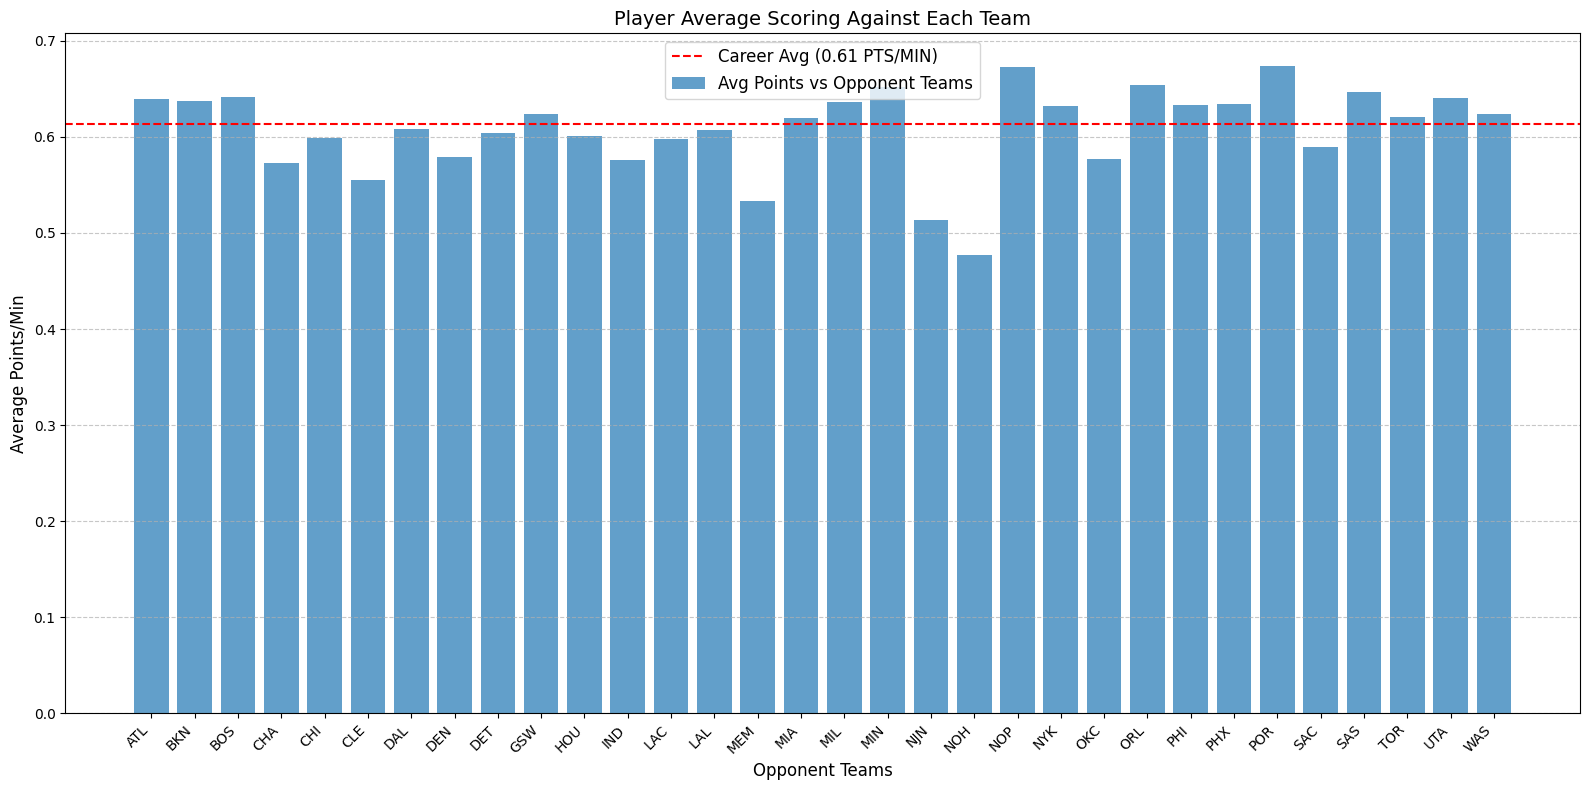

In [8]:
# Calculate career scoring per minute average
career_avg = player_stats["PTS"].mean()/player_stats["MIN"].mean()

# Calculate scoring averages against each opponent
team_avg = player_stats.groupby("Opponent")["PTS"].mean()/player_stats.groupby("Opponent")["MIN"].mean()

# Adjusted bar plot with better spacing for x-axis labels
plt.figure(figsize=(16, 8))  # Increased figure size for better spacing
bars = plt.bar(team_avg.index, team_avg.values, alpha=0.7, label='Avg Points vs Opponent Teams')

# Add a horizontal line for the career average
plt.axhline(career_avg, color='red', linestyle='--', linewidth=1.5, label=f'Career Avg ({career_avg:.2f} PTS/MIN)')

# Annotate each bar with the average value
#for bar in bars:
    #height = bar.get_height()
    #plt.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# Customize the plot
plt.title("Player Average Scoring Against Each Team", fontsize=14)
plt.xlabel("Opponent Teams", fontsize=12)
plt.ylabel("Average Points/Min", fontsize=12)
plt.xticks(rotation=45, fontsize=10, ha='right')  # Rotate and align x-axis labels
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()  # Ensures proper spacing
plt.show()


/var/folders/6h/jfqddf4979v3__m65vbr8r2m0000gn/T/ipykernel_8424/846416525.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spread_group_performance = merged_data.groupby("Spread_Group")["PTS"].mean()/merged_data.groupby("Spread_Group")["MIN"].mean()


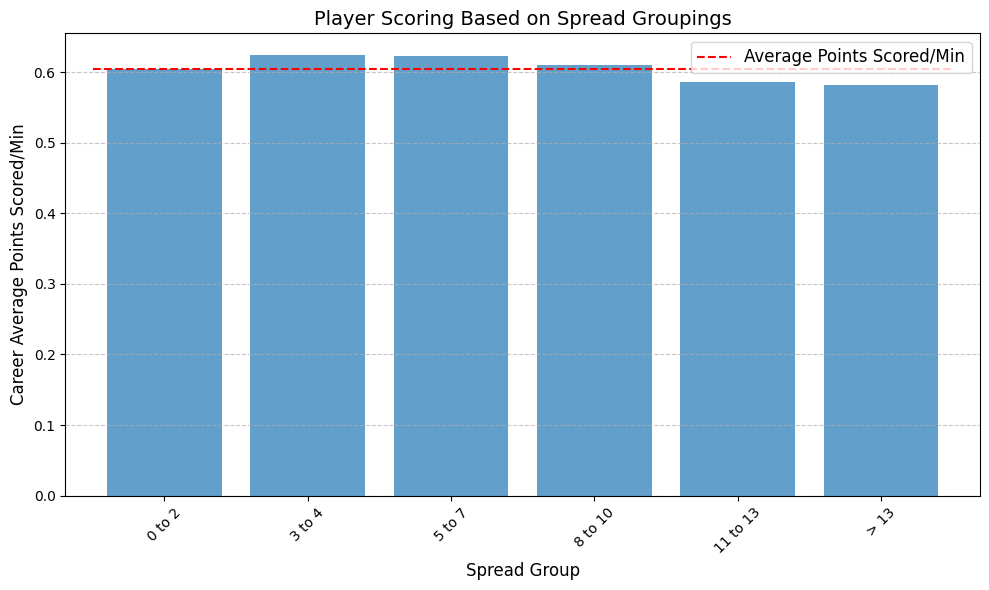

In [9]:
# Bin the spread values into groups
bins = [0, 2, 4, 7, 10, 13, float('inf')]
labels = ["0 to 2", "3 to 4", "5 to 7", "8 to 10", "11 to 13", "> 13"]
merged_data['Spread_Group'] = pd.cut(merged_data['spread'], bins=bins, labels=labels)

# Calculate average points scored for each spread group
spread_group_performance = merged_data.groupby("Spread_Group")["PTS"].mean()/merged_data.groupby("Spread_Group")["MIN"].mean()

# Plotting the data
plt.figure(figsize=(10, 6))
plt.hlines(y=spread_group_performance.mean(), xmin=-0.5, xmax=5.5, color='red', linestyle='--', label='Average Points Scored/Min')
plt.legend(fontsize=12)
plt.bar(spread_group_performance.index, spread_group_performance.values, alpha=0.7)
plt.title("Player Scoring Based on Spread Groupings", fontsize=14)
plt.xlabel("Spread Group", fontsize=12)
plt.ylabel("Career Average Points Scored/Min", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


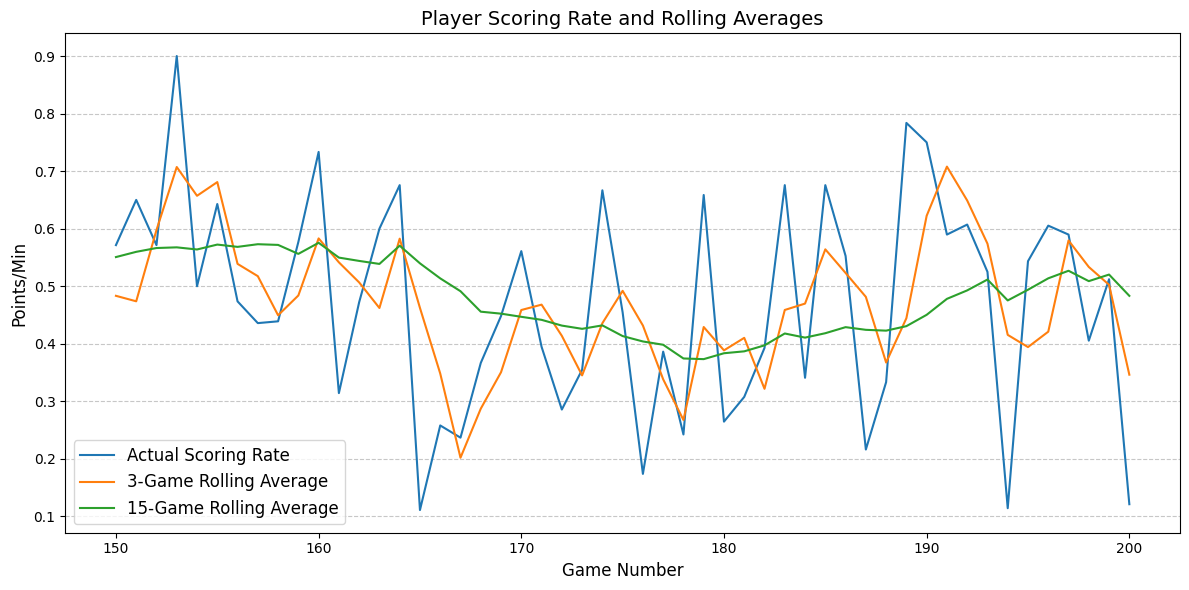

In [10]:
# make a line plot with the player actual scoring amount/min and the rolling averages over the course of event 150 to 200
plt.figure(figsize=(12, 6))
plt.plot(player_stats.loc[150:200, 'PTS_per_min'], label='Actual Scoring Rate')
plt.plot(player_stats.loc[150:200, 'PTS_per_min_rolling_3'], label='3-Game Rolling Average')
plt.plot(player_stats.loc[150:200, 'PTS_per_min_rolling_15'], label='15-Game Rolling Average')
plt.title("Player Scoring Rate and Rolling Averages", fontsize=14)
plt.xlabel("Game Number", fontsize=12)
plt.ylabel("Points/Min", fontsize=12)
plt.legend(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Feature Scaling and Model Training
Prepare data for linear regression and evaluate the model.

In [11]:
combined_data = merged_data.dropna(subset=['PTS', 'MIN', 'spread'])

In [12]:
show(combined_data)

In [13]:
selected_features = [
    # Contextual Features
    'Home_Court_Advantage',
    'Interdivisional_Game',
    'Rest_Category_2-3 days',
    'Rest_Category_Less than 2 days',
    'Rest_Category_More than 3 days',
    'spread',
    
    # Recent Performance Metrics
    'FGM_per_min_rolling_3',
    'FG3M_per_min_rolling_3',
    'FTM_per_min_rolling_3',
    'REB_per_min_rolling_3',
    'AST_per_min_rolling_3',
    'STL_per_min_rolling_3',
    'BLK_per_min_rolling_3',
    'TOV_per_min_rolling_3',
    'PTS_per_min_rolling_3',

    # Mid-Term Performance Metrics
    'FGM_per_min_rolling_7',
    'FG3M_per_min_rolling_7',
    'FTM_per_min_rolling_7',
    'REB_per_min_rolling_7',
    'AST_per_min_rolling_7',
    'STL_per_min_rolling_7',
    'BLK_per_min_rolling_7',
    'TOV_per_min_rolling_7',
    'PTS_per_min_rolling_7',

    # Long-Term Performance Metrics
    'FGM_per_min_rolling_15',
    'FG3M_per_min_rolling_15',
    'FTM_per_min_rolling_15',
    'REB_per_min_rolling_15',
    'AST_per_min_rolling_15',
    'STL_per_min_rolling_15',
    'BLK_per_min_rolling_15',
    'TOV_per_min_rolling_15',
    'PTS_per_min_rolling_15',

    # Target
    'Target'
]

working_df = combined_data[selected_features].copy()

In [14]:
working_df2 = working_df.loc[:,~working_df.columns.duplicated()]
X, Y = working_df2.drop(columns="Target"), working_df["Target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=23)


In [15]:
# %% [markdown]
# ## Train and Evaluate Models
# Import necessary libraries
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd


### Linear Regression 

In [16]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

# Predict and evaluate
lr_predictions = lr_model.predict(X_test)
lr_mape = mean_absolute_percentage_error(Y_test, lr_predictions)

### Ridge Regression 

In [17]:
# Train the model
ridge_model = Ridge()
ridge_model.fit(X_train, Y_train)

# Predict and evaluate
ridge_predictions = ridge_model.predict(X_test)
ridge_mape = mean_absolute_percentage_error(Y_test, ridge_predictions)

### Lasso Regression

In [18]:
# Train the model
lasso_model = Lasso()
lasso_model.fit(X_train, Y_train)

# Predict and evaluate
lasso_predictions = lasso_model.predict(X_test)
lasso_mape = mean_absolute_percentage_error(Y_test, lasso_predictions)

### Random Forest Model

In [19]:
# Train the model
rf_model = RandomForestRegressor(random_state=23)
rf_model.fit(X_train, Y_train)

# Predict and evaluate
rf_predictions = rf_model.predict(X_test)
rf_mape = mean_absolute_percentage_error(Y_test, rf_predictions)

### XGBoost

In [20]:
# Train the model
xgb_model = XGBRegressor(random_state=23)
xgb_model.fit(X_train, Y_train)

# Predict and evaluate
xgb_predictions = xgb_model.predict(X_test)
xgb_mape = mean_absolute_percentage_error(Y_test, xgb_predictions)

### LightGBM

In [21]:
# Train the model
lgb_model = LGBMRegressor(random_state=23)
lgb_model.fit(X_train, Y_train)

# Predict and evaluate
lgb_predictions = lgb_model.predict(X_test)
lgb_mape = mean_absolute_percentage_error(Y_test, lgb_predictions)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6376
[LightGBM] [Info] Number of data points in the train set: 757, number of used features: 33
[LightGBM] [Info] Start training from score 21.468956
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

## Compare Predictions

In [22]:
# Create a DataFrame to compare actual and predicted values
comparison_df = pd.DataFrame({
    "Actual": Y_test,
    "Linear_Regression": lr_predictions,
    "Ridge": ridge_predictions,
    "Lasso": lasso_predictions,
    "Random_Forest": rf_predictions,
    "XGBoost": xgb_predictions,
    "LightGBM": lgb_predictions
})

# Add errors for reference
comparison_df["Error_LR"] = abs(comparison_df["Actual"] - comparison_df["Linear_Regression"])
comparison_df["Error_Lasso"] = abs(comparison_df["Actual"] - comparison_df["Lasso"])
comparison_df["Error_Ridge"] = abs(comparison_df["Actual"] - comparison_df["Ridge"])
comparison_df["Error_RF"] = abs(comparison_df["Actual"] - comparison_df["Random_Forest"])
comparison_df["Error_XGB"] = abs(comparison_df["Actual"] - comparison_df["XGBoost"])
comparison_df["Error_LGB"] = abs(comparison_df["Actual"] - comparison_df["LightGBM"])


# %% [markdown]
# ### Summary of Results

# Create a summary DataFrame with MAPE scores
summary_df = pd.DataFrame({
    "Model": ["Linear Regression","Ridge","Lasso", "Random Forest", "XGBoost", "LightGBM"],
    "MAPE": [lr_mape,ridge_mape,lasso_mape, rf_mape, xgb_mape, lgb_mape]
}).sort_values(by="MAPE")



In [23]:
rf_mape

0.31270679260119566

In [24]:
# Round numeric columns in the comparison DataFrame
comparison_df = comparison_df.round({
    "Actual": 2,
    "Linear_Regression": 2,
    "Ridge": 2,
    "Lasso": 2,
    "Random_Forest": 2,
    "XGBoost": 2,
    "LightGBM": 2,
    "Error_LR": 2,
    "Error_Lasso": 2,
    "Error_Ridge": 2,
    "Error_RF": 2,
    "Error_XGB": 2,
    "Error_LGB": 2
})

# Create the summary DataFrame and round MAPE values
summary_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "Random Forest", "XGBoost", "LightGBM"],
    "MAPE": [lr_mape, ridge_mape, lasso_mape, rf_mape, xgb_mape, lgb_mape]
}).round({"MAPE": 2}).sort_values(by="MAPE")

In [25]:
show(comparison_df)
show(summary_df)

## Hyper Parameter Tuning 

In [26]:
# Define a small parameter grid for alpha
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

# Set up the grid search with 5-fold cross-validation
ridge_grid = GridSearchCV(
    Ridge(),
    param_grid,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Fit on training data
ridge_grid.fit(X_train, Y_train)

# Get the best estimator and evaluate
best_ridge_model = ridge_grid.best_estimator_
best_ridge_predictions = best_ridge_model.predict(X_test)
best_ridge_mape = mean_absolute_percentage_error(Y_test, best_ridge_predictions)

print("Best Ridge Alpha:", ridge_grid.best_params_)
print("Best Ridge CV Score (negative MAPE):", ridge_grid.best_score_)
print("Test MAPE of Best Ridge Model:", best_ridge_mape)


Fitting 5 folds for each of 5 candidates, totalling 25 fits


Best Ridge Alpha: {'alpha': 0.1}
Best Ridge CV Score (negative MAPE): -0.3469347997914142
Test MAPE of Best Ridge Model: 0.31335052498380145


In [27]:
# Define a small parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],  # Number of trees
    'max_depth': [5, 10, None],      # Maximum depth of each tree
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 5]    # Minimum samples at each leaf
}

# Set up the grid search with 5-fold cross-validation
rf_grid = GridSearchCV(
    RandomForestRegressor(),
    param_grid_rf,
    scoring='neg_mean_absolute_percentage_error',
    cv=5,
    n_jobs=-1,  # Use all available CPU cores
    verbose=1
)

# Fit on training data
rf_grid.fit(X_train, Y_train)

# Get the best estimator and evaluate on the test set
best_rf_model = rf_grid.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)
best_rf_mape = mean_absolute_percentage_error(Y_test, best_rf_predictions)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best Random Forest CV Score (negative MAPE):", rf_grid.best_score_)
print("Test MAPE of Best Random Forest Model:", best_rf_mape)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Random Forest Parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 200}
Best Random Forest CV Score (negative MAPE): -0.3680247576163674
Test MAPE of Best Random Forest Model: 0.33252945791495336


In [28]:
# coefficient p values for ridge regression
from sklearn.feature_selection import f_regression
f_values, p_values = f_regression(X_train, Y_train)
p_values = np.round(p_values, 5)
ridge_summary = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge_model.coef_,
    "P-Value": p_values
}).sort_values(by="P-Value")
ridge_summary

,Feature,Coefficient,P-Value
16,FG3M_per_min_rolling_7,1.835430,0.00000
28,AST_per_min_rolling_15,1.314287,0.00000
26,FTM_per_min_rolling_15,5.136156,0.00000
25,FG3M_per_min_rolling_15,2.075015,0.00000
24,FGM_per_min_rolling_15,-1.537299,0.00000
23,PTS_per_min_rolling_7,3.467319,0.00000
22,TOV_per_min_rolling_7,0.165406,0.00000
19,AST_per_min_rolling_7,-0.900490,0.00000
17,FTM_per_min_rolling_7,-3.331225,0.00000
31,TOV_per_min_rolling_15,-0.526104,0.00000


Making a sample of best model performance of random 15 data points

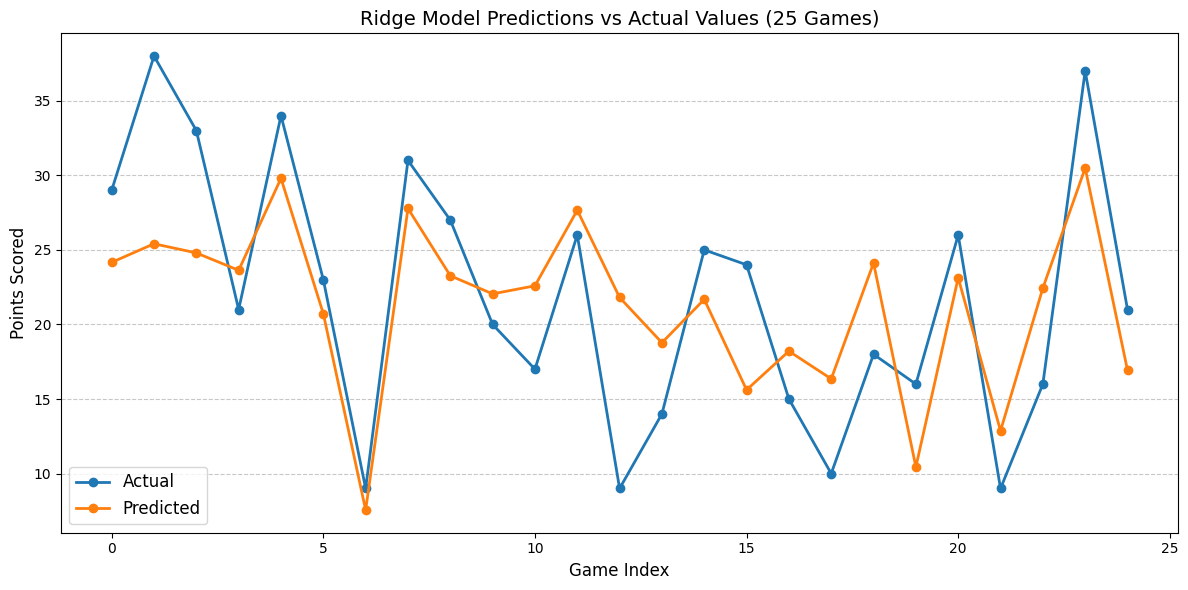

In [29]:
# Plot of Ridge Model Predictions vs Actual Values for 25 Random Games
import numpy as np

plt.figure(figsize=(12, 6))

# Plot actual values
plt.plot(range(25), Y_test[:25], marker='o', label='Actual', linewidth=2)

# Plot predicted values
plt.plot(range(25), ridge_predictions[:25], marker='o', label='Predicted', linewidth=2)


# Add title, labels, and legend
plt.title("Ridge Model Predictions vs Actual Values (25 Games)", fontsize=14)
plt.xlabel("Game Index", fontsize=12)
plt.ylabel("Points Scored", fontsize=12)
plt.legend(fontsize=12)


# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


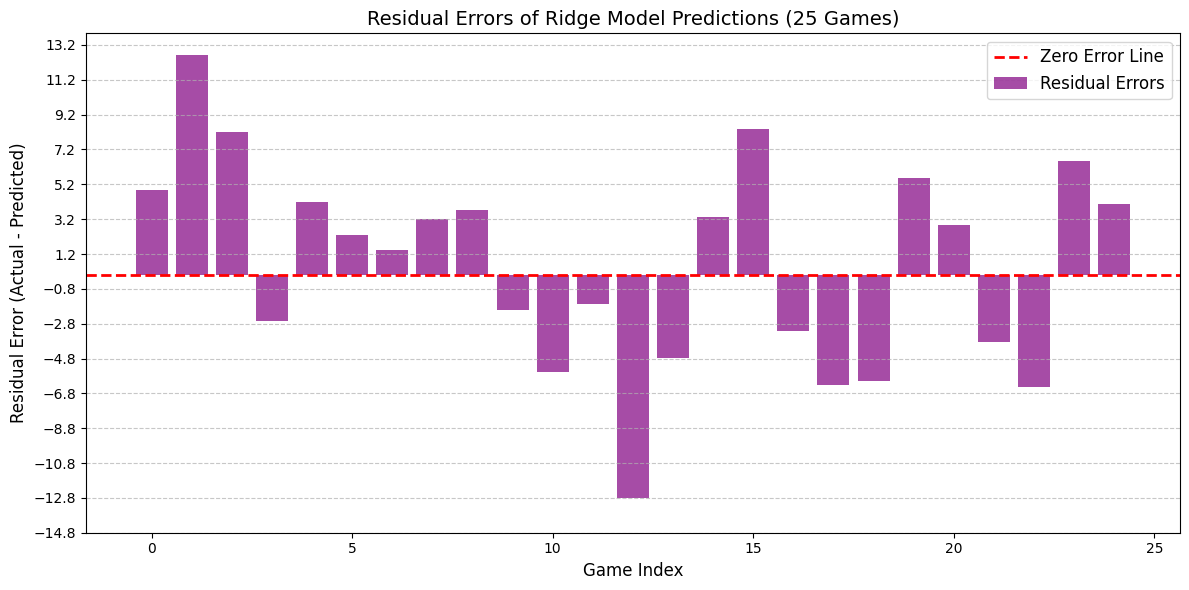

In [30]:
# Calculate residuals (errors)
residuals = Y_test[:25] - ridge_predictions[:25]

# Plot residuals with updated y-axis scale
plt.figure(figsize=(12, 6))
plt.bar(range(25), residuals, color="purple", alpha=0.7, label="Residual Errors")

# Add title, labels, and legend
plt.title("Residual Errors of Ridge Model Predictions (25 Games)", fontsize=14)
plt.xlabel("Game Index", fontsize=12)
plt.ylabel("Residual Error (Actual - Predicted)", fontsize=12)
plt.axhline(0, color="red", linestyle="--", linewidth=2, label="Zero Error Line")
plt.legend(fontsize=12)

# Set y-axis scale to count by 2s
plt.yticks(np.arange(min(residuals) - 2, max(residuals) + 2, 2))

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


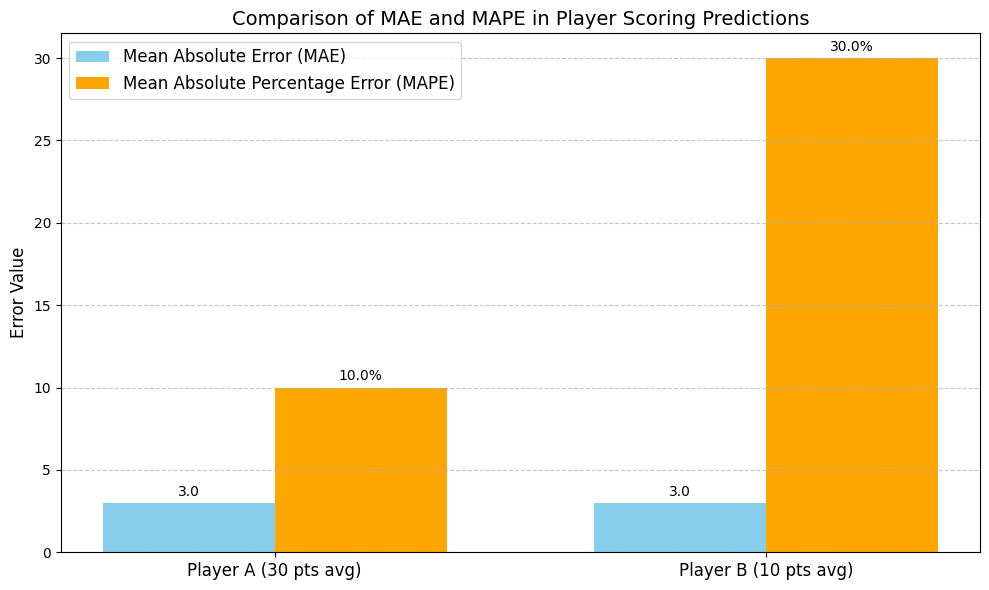

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Example data for the chart
players = ['Player A (30 pts avg)', 'Player B (10 pts avg)']
actual_scores = [30, 10]
predicted_scores = [27, 7]
absolute_errors = [abs(a - p) for a, p in zip(actual_scores, predicted_scores)]
mape = [(abs(a - p) / a) * 100 for a, p in zip(actual_scores, predicted_scores)]

# Plotting
x = np.arange(len(players))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bar1 = ax.bar(x - width/2, absolute_errors, width, label='Mean Absolute Error (MAE)', color='skyblue')
bar2 = ax.bar(x + width/2, mape, width, label='Mean Absolute Percentage Error (MAPE)', color='orange')

# Labels and Title
ax.set_title("Comparison of MAE and MAPE in Player Scoring Predictions", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(players, fontsize=12)
ax.set_ylabel("Error Value", fontsize=12)
ax.legend(fontsize=12)
ax.bar_label(bar1, padding=3, fmt='%.1f', fontsize=10)
ax.bar_label(bar2, padding=3, fmt='%.1f%%', fontsize=10)

# Grid and Layout
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()
